<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/Prac_09_Comparing_Machine_Learning_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9: Comparing machine learning algorithms


We have learned about four linear machine
learning algorithms: Linear Regression, Ridge Regression, LASSO Linear Regression and Elastic
Net Regression. You also learned about three nonlinear algorithms: k-Nearest Neighbors,
Classification and Regression Trees and Support Vector Machines.

Now we will discover
how to design simple experiments to directly compare machine learning algorithms to each other
on your dataset.

It is important to compare the performance of multiple different machine learning algorithms
consistently. In this chapter you will discover how you can create a test harness to compare
multiple different machine learning algorithms in Python with scikit-learn. You can use this
test harness as a template on your own machine learning problems and add more and different
algorithms to compare. After completing this lesson you will know:
1. How to formulate an experiment to directly compare machine learning algorithms.
2. A reusable template for evaluating the performance of multiple algorithms on one dataset.
3. How to report and visualize the results when comparing algorithm performance.

### Choose The Best Machine Learning Model

When you work on a machine learning project, you often end up with multiple good models
to choose from. Each model will have different performance characteristics. Using resampling
methods like cross validation, you can get an estimate for how accurate each model may be on
unseen data. You need to be able to use these estimates to choose one or two best models from
the suite of models that you have created.

When you have a new dataset, it is a good idea to visualize the data using different techniques in order to look at the data from different perspectives. The same idea applies to model selection.
You should use a number of different ways of looking at the estimated accuracy of your machine
learning algorithms in order to choose the one or two algorithm to finalize. A way to do this is
to use visualization methods to show the average accuracy, variance and other properties of the
distribution of model accuracies. In the next section you will discover exactly how you can do
that in Python with scikit-learn.

### Compare Machine Learning Algorithms Consistently

The key to a fair comparison of machine learning algorithms is ensuring that each algorithm is
evaluated in the same way on the same data. You can achieve this by forcing each algorithm to be evaluated on a consistent test harness. In the example below six different classification
algorithms are compared on a single dataset:
- Logistic Regression.
- Linear Discriminant Analysis.
- k-Nearest Neighbors.
- Classification and Regression Trees.
- Naive Bayes.
- Support Vector Machines.

The dataset is the corrosion ship  problem. The problem has two classes and eight numeric input variables of varying scales. The 10-fold cross validation procedure is used to evaluate each algorithm, importantly configured with the same random seed to ensure that the same splits to the training data are performed and that each algorithm is evaluated in precisely the same way. Each algorithm is given a short name, useful for summarizing results afterward.

---
**Load the file from a url to `content/data_sample`**

---

First of all we will load the file from a url and then save it in `content/data_sample`.

In [1]:
!wget -O /content/sample_data/Corrosion_Detection_Ships.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Corrosion_Detection_Ships.csv

--2025-03-30 07:14:39--  https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Corrosion_Detection_Ships.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23278 (23K) [text/plain]
Saving to: ‘/content/sample_data/Corrosion_Detection_Ships.csv’

/content/sample_dat 100%[===================>]  22.73K  --.-KB/s    in 0.001s  

2025-03-30 07:14:39 (32.5 MB/s) - ‘/content/sample_data/Corrosion_Detection_Ships.csv’ saved [23278/23278]



---
**Compare Algorithms**

---

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LR: 0.778640 (0.047350)
LDA: 0.766969 (0.047966)
KNN: 0.710988 (0.050792)
CART: 0.695403 (0.046009)
NB: 0.759142 (0.038960)
SVM: 0.760458 (0.034712)


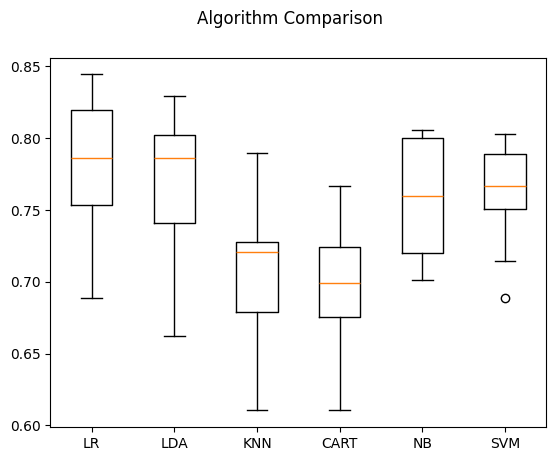

In [4]:
# Compare Algorithms
from pandas import read_csv
from matplotlib import pyplot
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
# load dataset
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
              'Water_salinity',
              'Water_pressure',
              'Coating_thickness',
              'Anti_corrosion_concentration',
              'Hull_material_density',
              'Inspection_history',
              'Ship_age',
              'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
# prepare models
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))
# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
  kfold = KFold(n_splits=10, random_state=7, shuffle=True)
  cv_results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)
# boxplot algorithm comparison
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()